# Results Analysis - Publication-Ready Visualizations

**Zweck:** Erstellt die 4 Kern-Visualisierungen für die Thesis

**Input:** `results_combined.csv`

**Output:** 4 PNG-Dateien (publication-ready)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Styling für Publication-Quality
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

# Color palette
FLAT_COLOR = '#3498db'      # Blue
HIER_COLOR = '#e74c3c'      # Red
COLORS = [FLAT_COLOR, HIER_COLOR]

print("✅ Setup complete")

✅ Setup complete


## 1. Load Data

In [2]:
# Paths - robust detection of project root
import os

# Get current working directory
cwd = Path(os.getcwd())
print(f"Current working directory: {cwd}")

# Find project root (look for 'results' directory)
if (cwd / 'results').exists():
    # Already in project root
    project_root = cwd
elif (cwd.parent / 'results').exists():
    # In notebooks/ subdirectory
    project_root = cwd.parent
elif (cwd / 'BA' / 'results').exists():
    # In Desktop
    project_root = cwd / 'BA'
else:
    # Manual fallback - ADJUST THIS PATH IF NEEDED
    project_root = Path(r'C:\Users\Julian\Desktop\BA')
    print(f"⚠️  Using manual path: {project_root}")

results_file = project_root / 'results' / 'evaluation' / 'results_combined.csv'
output_dir = project_root / 'results' / 'visualizations'

# Create output directory
output_dir.mkdir(parents=True, exist_ok=True)

print(f"\n📂 Project root: {project_root}")
print(f"📂 Output dir: {output_dir}")
print(f"📂 Results file: {results_file}")

# Check if results file exists
if not results_file.exists():
    print(f"\n❌ ERROR: Results file not found!")
    print(f"   Expected: {results_file}")
    print(f"   Please check the path or run 03_run_evaluation.py first!")
    raise FileNotFoundError(f"Results file not found: {results_file}")
else:
    print(f"\n✅ Results file found")

# Load
df = pd.read_csv(results_file)

print(f"✅ Data loaded: {len(df)} rows")

Current working directory: C:\Users\Julian\Desktop\BA\notebooks

📂 Project root: C:\Users\Julian\Desktop\BA
📂 Output dir: C:\Users\Julian\Desktop\BA\results\visualizations
📂 Results file: C:\Users\Julian\Desktop\BA\results\evaluation\results_combined.csv

✅ Results file found
✅ Data loaded: 294 rows


## 2. Plot 1: Recall@k Comparison (Line Plot)

**Zeigt:** Wie entwickelt sich Recall mit steigendem k?

✅ Saved: C:\Users\Julian\Desktop\BA\results\visualizations\01_recall_at_k_comparison.png
   Full path: C:\Users\Julian\Desktop\BA\results\visualizations\01_recall_at_k_comparison.png


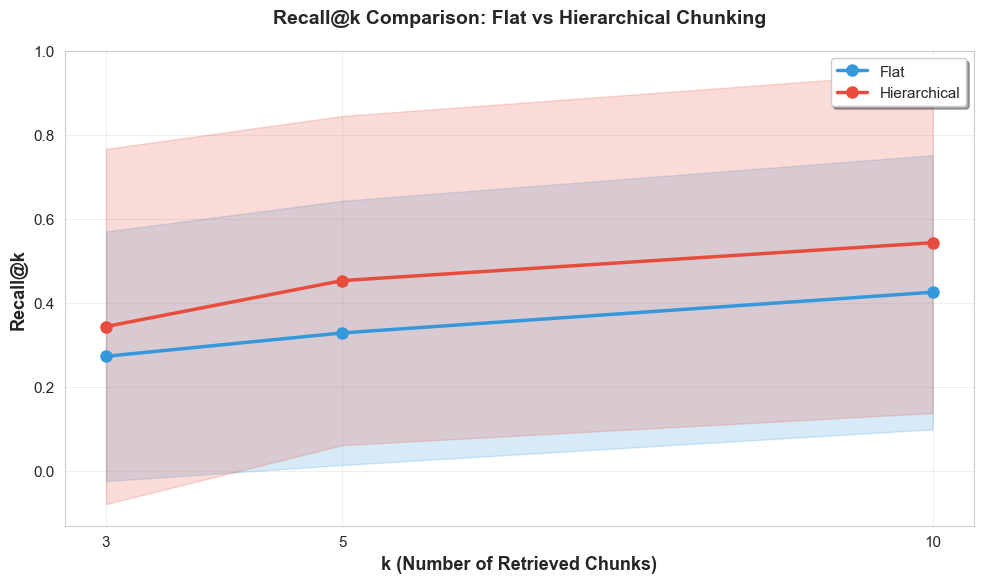

In [3]:
# Aggregate by k and mode
recall_by_k = df.groupby(['k', 'mode'])['recall'].agg(['mean', 'std']).reset_index()

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

for mode, color in zip(['flat', 'hierarchical'], COLORS):
    data = recall_by_k[recall_by_k['mode'] == mode]
    
    ax.plot(data['k'], data['mean'], 
            marker='o', linewidth=2.5, markersize=8,
            label=mode.capitalize(), color=color)
    
    # Error bands (optional)
    ax.fill_between(data['k'], 
                     data['mean'] - data['std'],
                     data['mean'] + data['std'],
                     alpha=0.2, color=color)

ax.set_xlabel('k (Number of Retrieved Chunks)', fontweight='bold')
ax.set_ylabel('Recall@k', fontweight='bold')
ax.set_title('Recall@k Comparison: Flat vs Hierarchical Chunking', 
             fontweight='bold', pad=20)
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.set_xticks([3, 5, 10])

plt.tight_layout()

# Save BEFORE show (important!)
output_file = output_dir / '01_recall_at_k_comparison.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file}")
print(f"   Full path: {output_file.absolute()}")

plt.show()

## 3. Plot 2: Performance by Question Type (Grouped Bar Chart)

**Zeigt:** Welche Fragentypen profitieren von welcher Strategie?

✅ Saved: C:\Users\Julian\Desktop\BA\results\visualizations\02_performance_by_type.png
   Full path: C:\Users\Julian\Desktop\BA\results\visualizations\02_performance_by_type.png


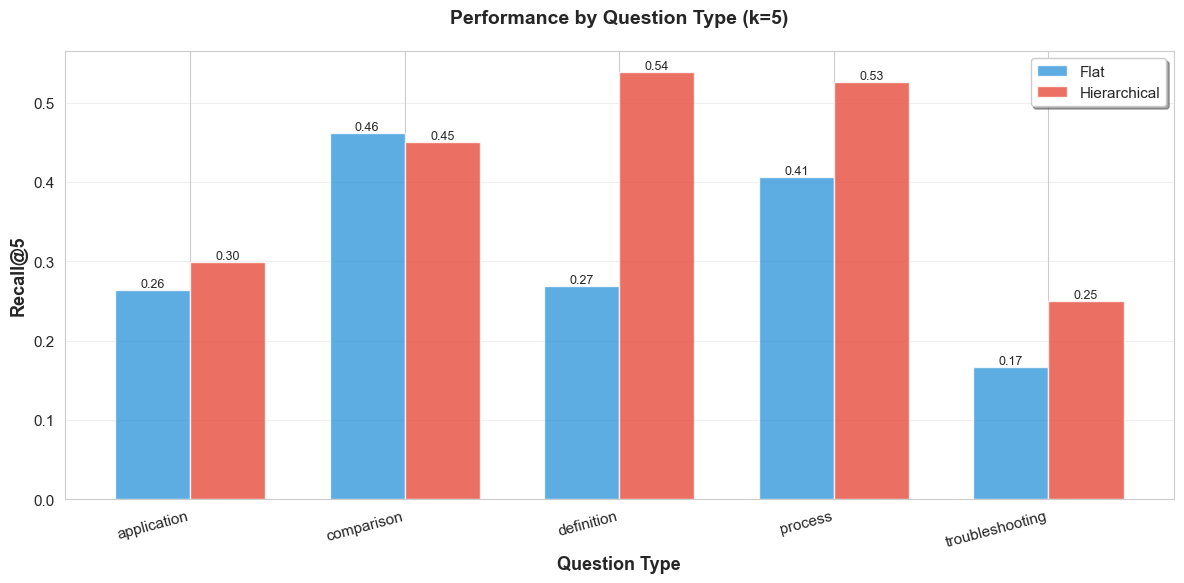

In [4]:
# Filter k=5
df_k5 = df[df['k'] == 5]

# Aggregate by type and mode
by_type = df_k5.groupby(['type', 'mode'])['recall'].mean().reset_index()

# Pivot for grouped bar chart
by_type_pivot = by_type.pivot(index='type', columns='mode', values='recall')

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(by_type_pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, by_type_pivot['flat'], width, 
               label='Flat', color=FLAT_COLOR, alpha=0.8)
bars2 = ax.bar(x + width/2, by_type_pivot['hierarchical'], width,
               label='Hierarchical', color=HIER_COLOR, alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Question Type', fontweight='bold')
ax.set_ylabel('Recall@5', fontweight='bold')
ax.set_title('Performance by Question Type (k=5)', 
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(by_type_pivot.index, rotation=15, ha='right')
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save BEFORE show
output_file = output_dir / '02_performance_by_type.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file}")
print(f"   Full path: {output_file.absolute()}")

plt.show()

## 4. Plot 3: MRR Comparison (Bar Chart with Error Bars)

**Zeigt:** Ranking-Qualität im Vergleich

✅ Saved: C:\Users\Julian\Desktop\BA\results\visualizations\03_mrr_comparison.png
   Full path: C:\Users\Julian\Desktop\BA\results\visualizations\03_mrr_comparison.png


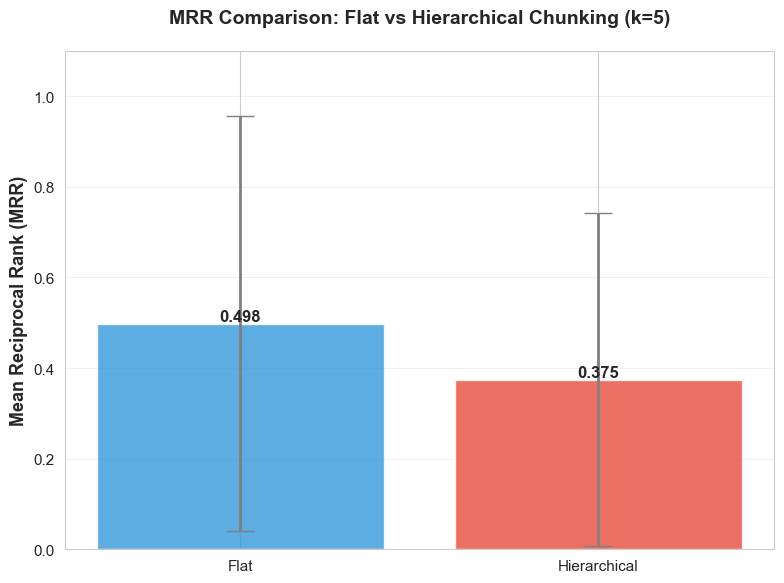

In [5]:
# Aggregate MRR for k=5
mrr_stats = df_k5.groupby('mode')['mrr'].agg(['mean', 'std']).reset_index()

# Create plot
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(mrr_stats))
bars = ax.bar(x, mrr_stats['mean'], 
              color=COLORS, alpha=0.8,
              yerr=mrr_stats['std'], capsize=10,
              error_kw={'linewidth': 2, 'ecolor': 'gray'})

# Add value labels
for i, (bar, mean_val) in enumerate(zip(bars, mrr_stats['mean'])):
    ax.text(bar.get_x() + bar.get_width()/2., mean_val,
            f'{mean_val:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Mean Reciprocal Rank (MRR)', fontweight='bold')
ax.set_title('MRR Comparison: Flat vs Hierarchical Chunking (k=5)', 
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['Flat', 'Hierarchical'])
ax.grid(True, alpha=0.3, axis='y')

# Calculate proper y-limit to show error bars completely
max_with_error = (mrr_stats['mean'] + mrr_stats['std']).max()
ax.set_ylim(0, max_with_error * 1.15)  # 15% padding above error bars

plt.tight_layout()

# Save BEFORE show
output_file = output_dir / '03_mrr_comparison.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file}")
print(f"   Full path: {output_file.absolute()}")

plt.show()

## 5. Plot 4: Performance by Difficulty (Grouped Bar Chart)

**Zeigt:** Wie performen die Strategien je nach Schwierigkeit?

✅ Saved: C:\Users\Julian\Desktop\BA\results\visualizations\04_performance_by_difficulty.png
   Full path: C:\Users\Julian\Desktop\BA\results\visualizations\04_performance_by_difficulty.png


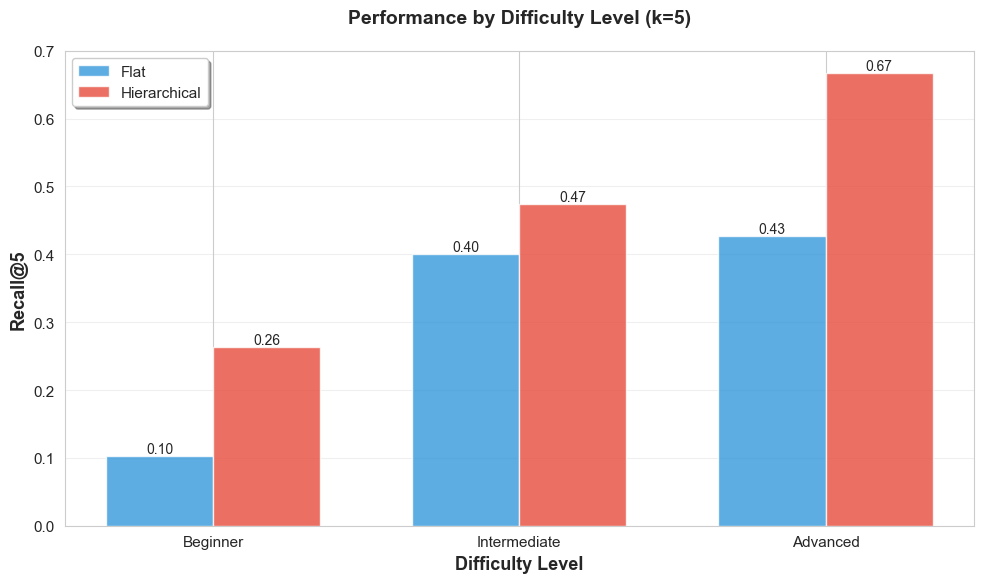

In [6]:
# Aggregate by difficulty and mode
by_diff = df_k5.groupby(['difficulty', 'mode'])['recall'].mean().reset_index()

# Pivot
by_diff_pivot = by_diff.pivot(index='difficulty', columns='mode', values='recall')

# Reorder for logical progression
difficulty_order = ['beginner', 'intermediate', 'advanced']
by_diff_pivot = by_diff_pivot.reindex(difficulty_order)

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(by_diff_pivot.index))
width = 0.35

bars1 = ax.bar(x - width/2, by_diff_pivot['flat'], width,
               label='Flat', color=FLAT_COLOR, alpha=0.8)
bars2 = ax.bar(x + width/2, by_diff_pivot['hierarchical'], width,
               label='Hierarchical', color=HIER_COLOR, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Difficulty Level', fontweight='bold')
ax.set_ylabel('Recall@5', fontweight='bold')
ax.set_title('Performance by Difficulty Level (k=5)',
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in by_diff_pivot.index])
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save BEFORE show
output_file = output_dir / '04_performance_by_difficulty.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file}")
print(f"   Full path: {output_file.absolute()}")

plt.show()

## 6. Summary

**Alle 4 Visualisierungen erstellt!**

**Output-Dateien:**
1. `01_recall_at_k_comparison.png` - Recall über verschiedene k-Werte
2. `02_performance_by_type.png` - Performance nach Fragentyp
3. `03_mrr_comparison.png` - MRR Vergleich mit Error Bars
4. `04_performance_by_difficulty.png` - Performance nach Schwierigkeit

**Format:** 300 DPI, publication-ready

**Verwendung in Thesis:**
- Direkt einfügbar in Word/LaTeX
- Hohe Qualität für Druck
- Konsistentes Styling

In [ ]:
# List all generated files
print("\n📊 Generated Visualizations:")
print("="*50)
for file in sorted(output_dir.glob('*.png')):
    size_kb = file.stat().st_size / 1024
    print(f"✅ {file.name:<40} ({size_kb:.0f} KB)")

print("\n💡 Ready for thesis integration!")